In [7]:
from pathlib import Path

import pandas as pd

DATA_FILE_NAME = "telco_churn_cleaned.xlsx"
search_paths = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / "01_eda_and_insights.ipynb",
]
DATA_FILE = next(
    (
        directory / DATA_FILE_NAME
        for directory in search_paths
        if (directory / DATA_FILE_NAME).is_file()
    ),
    None,
)

if DATA_FILE is None:
    searched_paths = [str(directory / DATA_FILE_NAME) for directory in search_paths]
    raise FileNotFoundError(
        f"Could not find {DATA_FILE_NAME}. Searched: {searched_paths}"
    )

try:
    df = pd.read_excel(DATA_FILE)
except ImportError as exc:
    raise ImportError(
        "Excel support is unavailable. Install openpyxl in this notebook's Python environment."
    ) from exc
except Exception as exc:
    raise RuntimeError(f"Unable to read {DATA_FILE}: {exc}") from exc

if "Churn" not in df.columns:
    raise ValueError("The dataset is missing the required 'Churn' target column.")

row_count, column_count = df.shape
print(f"Loaded file: {DATA_FILE.resolve()}")
print(f"Dataset dimensions: {row_count:,} rows x {column_count:,} columns")

missing_by_column = df.isna().sum()
missing_total = int(missing_by_column.sum())
if missing_total == 0:
    print("Missing values: 0 (verified)")
else:
    print(f"Missing values: {missing_total:,} (review the affected columns below)")
    print(missing_by_column[missing_by_column > 0].to_string())

churn_counts = df["Churn"].value_counts(dropna=False)
churn_percentages = df["Churn"].value_counts(dropna=False, normalize=True) * 100
churn_summary = pd.DataFrame(
    {
        "Count": churn_counts.astype(int),
        "Percentage": churn_percentages.map(lambda value: f"{value:.2f}%"),
    }
)
churn_summary.index.name = "Churn"
print("\nBaseline Churn distribution:")
display(churn_summary)

print("\nFirst 3 rows:")
display(df.head(3))

Loaded file: C:\Important GHN files\telco-churn-intelligence\01_eda_and_insights.ipynb\telco_churn_cleaned.xlsx
Dataset dimensions: 7,043 rows x 21 columns
Missing values: 0 (verified)

Baseline Churn distribution:


,Count,Percentage
Churn,,
No,5174,73.46%
Yes,1869,26.54%



First 3 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


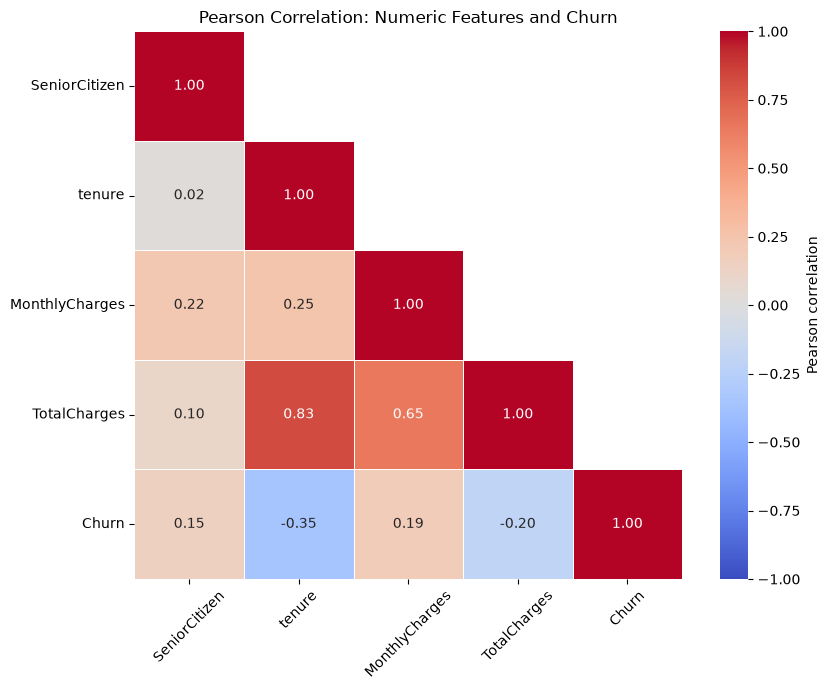

Pearson correlations with Churn, sorted by absolute strength:
tenure           -0.352229
TotalCharges     -0.199484
MonthlyCharges    0.193356
SeniorCitizen     0.150889


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

correlation_data = df.select_dtypes(include="number").copy()
correlation_data["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
correlation_data["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

correlation = correlation_data.corr(method="pearson")
upper_triangle_mask = np.triu(np.ones_like(correlation, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    correlation,
    mask=upper_triangle_mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson correlation"},
    ax=ax,
)
ax.set_title("Pearson Correlation: Numeric Features and Churn")
ax.tick_params(axis="x", labelrotation=45)
ax.tick_params(axis="y", labelrotation=0)
plt.tight_layout()
plt.show()

print("Pearson correlations with Churn, sorted by absolute strength:")
print(correlation["Churn"].drop("Churn").sort_values(key=abs, ascending=False).to_string())

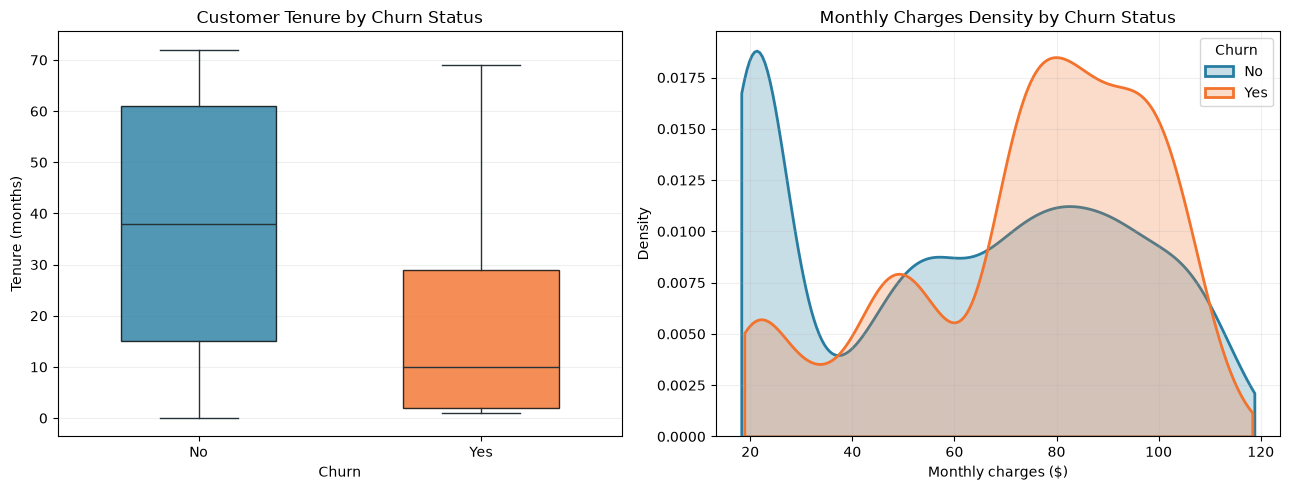

Median tenure and monthly charges by churn status:
       tenure  MonthlyCharges
Churn                        
No       38.0           64.43
Yes      10.0           79.65


In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plot_data = df.copy()
plot_data["tenure"] = pd.to_numeric(plot_data["tenure"], errors="coerce")
plot_data["MonthlyCharges"] = pd.to_numeric(plot_data["MonthlyCharges"], errors="coerce")
plot_data = plot_data.dropna(subset=["tenure", "MonthlyCharges", "Churn"])

churn_order = ["No", "Yes"]
churn_colors = {"No": "#277DA1", "Yes": "#F3722C"}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for position, churn_label in enumerate(churn_order, start=1):
    tenure_values = plot_data.loc[plot_data["Churn"] == churn_label, "tenure"]
    box = axes[0].boxplot(
        tenure_values,
        positions=[position],
        widths=0.55,
        patch_artist=True,
        showfliers=False,
    )
    box["boxes"][0].set_facecolor(churn_colors[churn_label])
    box["boxes"][0].set_alpha(0.8)
    for element in ("whiskers", "caps", "medians"):
        for artist in box[element]:
            artist.set_color("#263238")

axes[0].set_xticks([1, 2], churn_order)
axes[0].set_title("Customer Tenure by Churn Status")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Tenure (months)")
axes[0].grid(axis="y", alpha=0.2)

for churn_label in churn_order:
    charges = plot_data.loc[
        plot_data["Churn"] == churn_label, "MonthlyCharges"
    ]
    sns.kdeplot(
        x=charges,
        fill=True,
        alpha=0.25,
        linewidth=2,
        cut=0,
        clip=(18, 120),
        color=churn_colors[churn_label],
        label=churn_label,
        ax=axes[1],
    )

axes[1].set_title("Monthly Charges Density by Churn Status")
axes[1].set_xlabel("Monthly charges ($)")
axes[1].set_ylabel("Density")
axes[1].legend(title="Churn")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("Median tenure and monthly charges by churn status:")
print(
    plot_data.groupby("Churn", observed=True)[["tenure", "MonthlyCharges"]]
    .median()
    .round(2)
    .to_string()
)


Churn Rate by Contract Type (rate and group size):
      Contract  Customers Churn rate (%)
Month-to-month       3875          42.71
      One year       1473          11.27
      Two year       1695           2.83

Churn Rate by Tech Support (rate and group size):
        TechSupport  Customers Churn rate (%)
                 No       3473          41.64
                Yes       2044          15.17
No internet service       1526           7.40


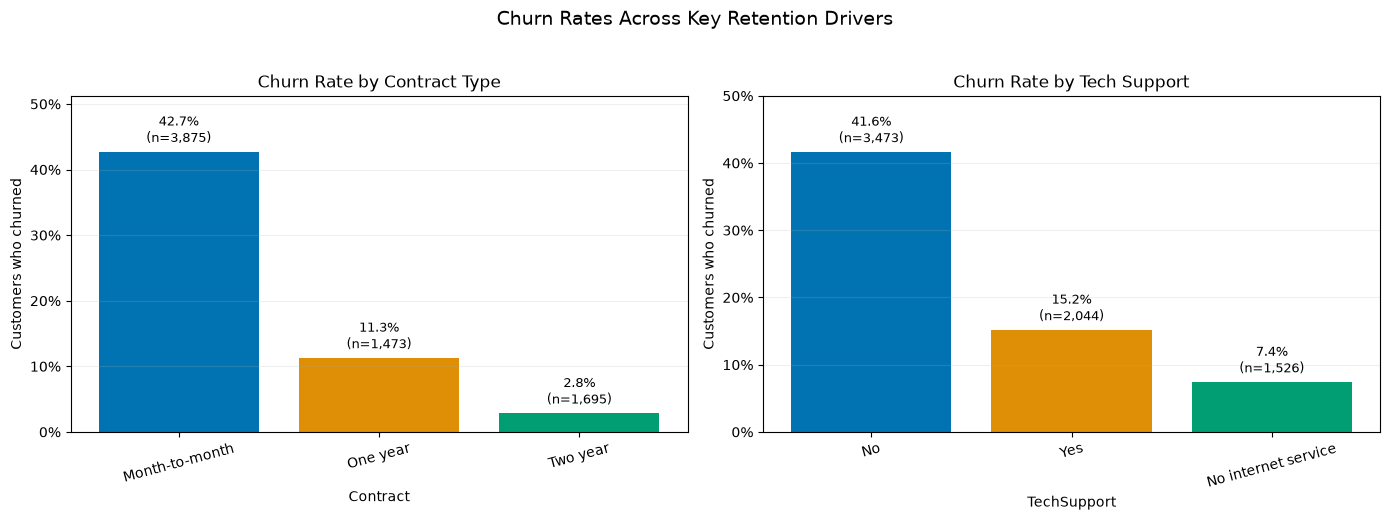

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.ticker import PercentFormatter

category_data = df[["Contract", "TechSupport", "Churn"]].copy()
category_data["churn_flag"] = category_data["Churn"].eq("Yes").astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
chart_specs = [
    ("Contract", "Churn Rate by Contract Type"),
    ("TechSupport", "Churn Rate by Tech Support"),
]

for ax, (category_column, title) in zip(axes, chart_specs):
    summary = (
        category_data.groupby(category_column, dropna=False)
        .agg(churn_rate=("churn_flag", "mean"), customers=("churn_flag", "size"))
        .reset_index()
    )
    summary["churn_rate_pct"] = summary["churn_rate"] * 100
    summary = summary.sort_values("churn_rate_pct", ascending=False)
    labels = summary[category_column].fillna("Unknown").astype(str).tolist()
    colors = sns.color_palette("colorblind", n_colors=len(summary))
    bars = ax.bar(labels, summary["churn_rate_pct"], color=colors)

    for bar, rate, customer_count in zip(
        bars, summary["churn_rate_pct"], summary["customers"]
    ):
        ax.annotate(
            f"{rate:.1f}%\n(n={customer_count:,})",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.set_title(title)
    ax.set_xlabel(category_column)
    ax.set_ylabel("Customers who churned")
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.set_ylim(0, max(50, summary["churn_rate_pct"].max() * 1.2))
    ax.tick_params(axis="x", labelrotation=15)
    ax.grid(axis="y", alpha=0.2)

    print(f"\n{title} (rate and group size):")
    print(
        summary[[category_column, "customers", "churn_rate_pct"]]
        .rename(columns={"customers": "Customers", "churn_rate_pct": "Churn rate (%)"})
        .to_string(index=False, formatters={"Churn rate (%)": "{:.2f}".format})
    )

fig.suptitle("Churn Rates Across Key Retention Drivers", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()